# Assignment_3_PCA_Dimensionality_Reduction

Apply dimensionality reduction using PCA.


## Aim
Reduce the dimensionality of the Iris dataset using Principal Component Analysis (PCA).

Result folder: /content/results


,Component,Explained_Variance
0,PC1,0.729624
1,PC2,0.228508
2,Total,0.958132


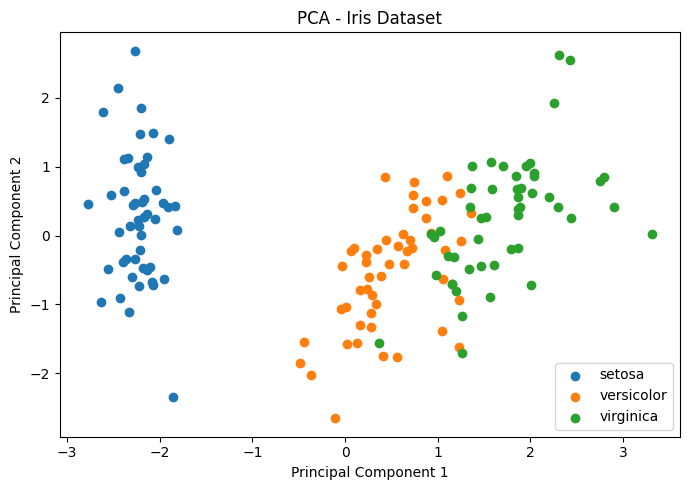

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULT_DIR = "/content/results"
os.makedirs(RESULT_DIR, exist_ok=True)

print("Result folder:", RESULT_DIR)

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

iris = load_iris()
X = StandardScaler().fit_transform(iris.data)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

metrics = pd.DataFrame({
    "Component":["PC1","PC2","Total"],
    "Explained_Variance":[pca.explained_variance_ratio_[0],
                          pca.explained_variance_ratio_[1],
                          pca.explained_variance_ratio_.sum()]
})
display(metrics)

plt.figure(figsize=(7,5))
for i, name in enumerate(iris.target_names):
    plt.scatter(X_pca[iris.target==i,0], X_pca[iris.target==i,1], label=name)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - Iris Dataset")
plt.legend()
plt.tight_layout()
plt.savefig(f"{RESULT_DIR}/pca_plot.png", dpi=150)
plt.show()

metrics.to_csv(f"{RESULT_DIR}/pca_results.csv", index=False)
pd.DataFrame(X_pca, columns=["PC1","PC2"]).to_csv(f"{RESULT_DIR}/pca_transformed_data.csv", index=False)


In [ ]:
import shutil
from google.colab import files
shutil.make_archive("/content/Assignment_3_Results", "zip", RESULT_DIR)
files.download("/content/Assignment_3_Results.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>